In [1]:
# Cell 1 — Imports and setup
import sys
from pathlib import Path

# Add src/ to the path so we can import dataset.py
project_root = Path.cwd().parent  # notebook is in notebooks/, project root is one level up
sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np
from dataset import PowderDataset, get_class_names

print(f"Project root: {project_root}")
print(f"Data folder: {project_root / 'data'}")

Project root: c:\Users\USER\Desktop\Master Thesis
Data folder: c:\Users\USER\Desktop\Master Thesis\data


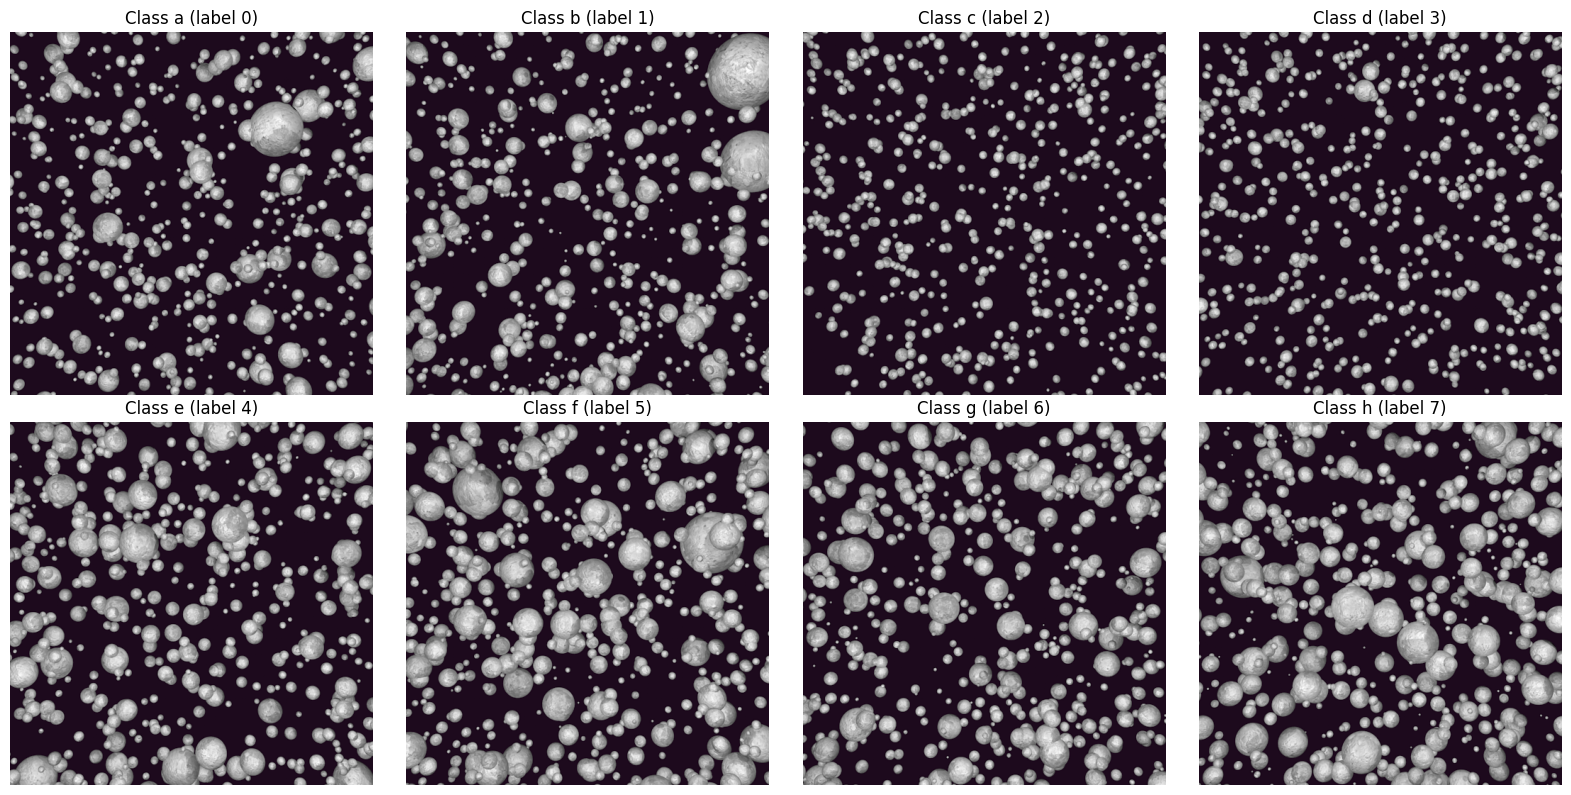

Saved figure to results/01_one_per_class.png


In [2]:
# Cell 2 — Display one image from each of the 8 classes
data_root = project_root / "data"
train_ds = PowderDataset(data_root, split="train")
class_names = get_class_names()

# Find the first image of each class
first_per_class = {}
for img_path, label in train_ds.samples:
    if label not in first_per_class:
        first_per_class[label] = img_path
    if len(first_per_class) == 8:
        break

# Plot them in a 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for label in range(8):
    ax = axes[label // 4, label % 4]
    img = plt.imread(first_per_class[label])
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Class {class_names[label]} (label {label})", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig(project_root / "results" / "01_one_per_class.png", dpi=100, bbox_inches="tight")
plt.show()

print("Saved figure to results/01_one_per_class.png")

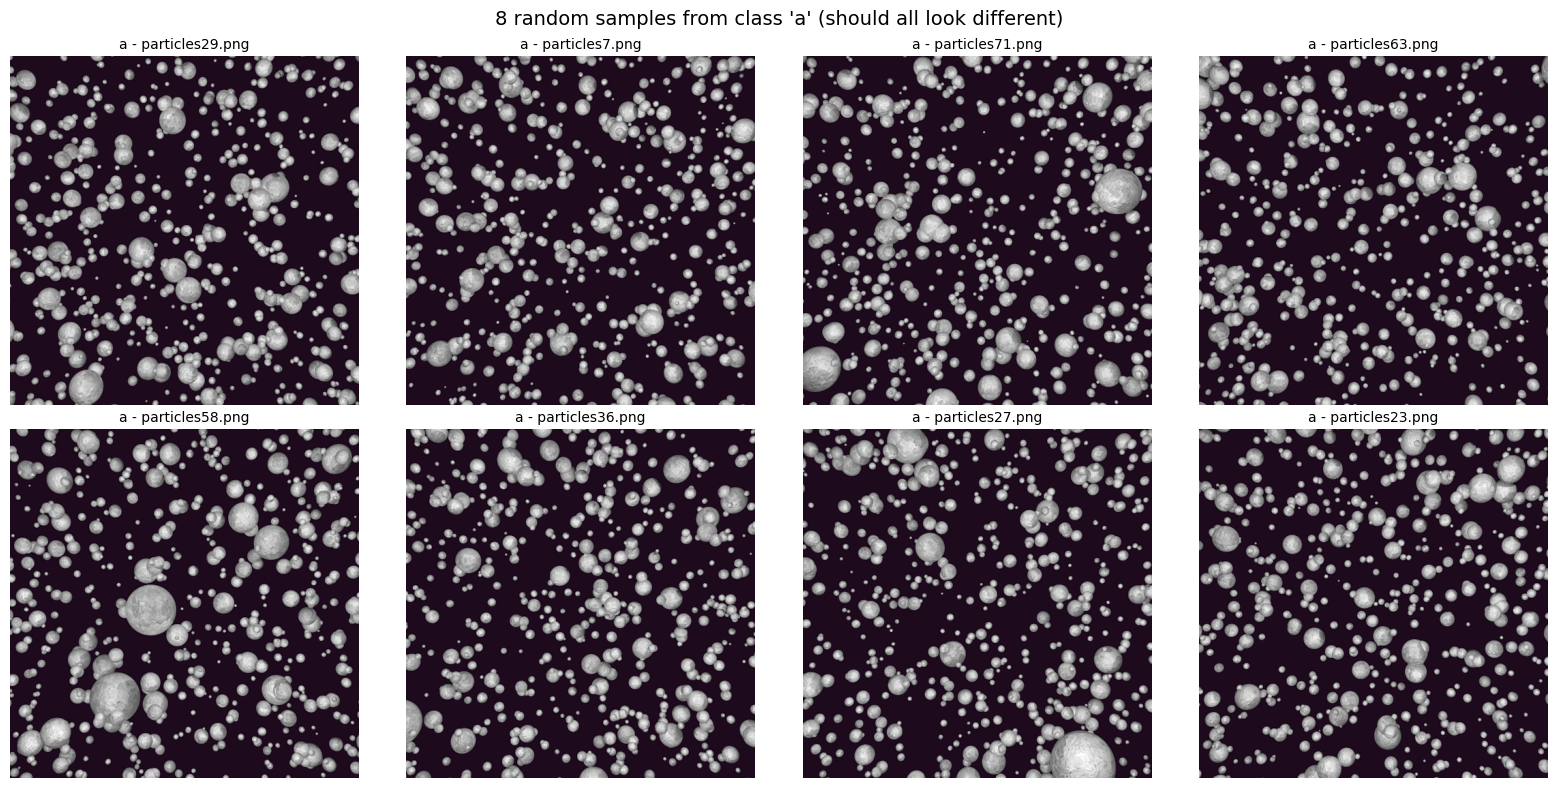

In [3]:
# Cell 3 — Multiple images from class 'a' to check for variation
import random
random.seed(42)  # reproducible

# Get all images of class 'a' (label=0)
class_a_paths = [path for path, label in train_ds.samples if label == 0]

# Pick 8 random ones
sample_paths = random.sample(class_a_paths, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, path in enumerate(sample_paths):
    ax = axes[i // 4, i % 4]
    img = plt.imread(path)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"a - {path.name}", fontsize=10)
    ax.axis("off")

plt.suptitle("8 random samples from class 'a' (should all look different)", fontsize=14)
plt.tight_layout()
plt.savefig(project_root / "results" / "02_within_class_a.png", dpi=100, bbox_inches="tight")
plt.show()

In [4]:
# Cell 4 — Pixel statistics across the training set
import numpy as np
from PIL import Image
from tqdm import tqdm

# Sample 100 random training images and compute stats
np.random.seed(42)
sample_indices = np.random.choice(len(train_ds), size=100, replace=False)

pixel_means = []
pixel_stds = []
for idx in tqdm(sample_indices, desc="Computing pixel stats"):
    img, _ = train_ds[idx]
    arr = np.asarray(img, dtype=np.float32) / 255.0  # normalize to 0-1
    pixel_means.append(arr.mean())
    pixel_stds.append(arr.std())

print(f"Mean pixel intensity:        {np.mean(pixel_means):.4f} (std across images: {np.std(pixel_means):.4f})")
print(f"Mean pixel std (per image):  {np.mean(pixel_stds):.4f}")
print(f"\nFor reference: a mostly-black image with bright spots will have low mean (~0.1-0.3)")

Computing pixel stats: 100%|██████████| 100/100 [00:01<00:00, 54.22it/s]

Mean pixel intensity:        0.2646 (std across images: 0.0577)
Mean pixel std (per image):  0.2671

For reference: a mostly-black image with bright spots will have low mean (~0.1-0.3)
